# Brief

The point of this notebook is to show that the frequency information of a sinusoid can be recovered from the spike timings.

It should be relatively self-evident that spike frequency should recover signal frequencies.  It generally known that capacitors can be used to create analog fourier banks, and the neuron is functionally modelled as an RC circuit.

In [1]:
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
from spike.v1 import (
  DefaultRecvNeuronModel,
  DefaultDataNeuronModel
)

Now, let's simulate a frequency.

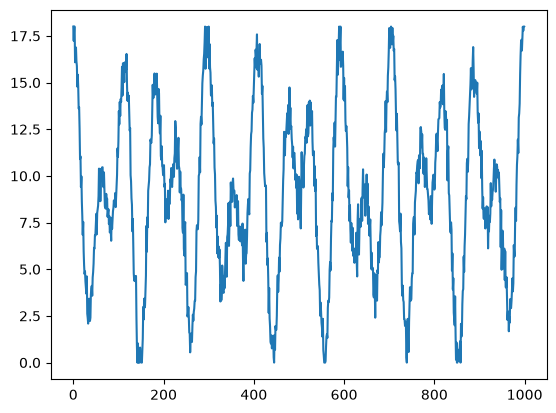

In [2]:
def create_signal(
    samples: int,
    cycles: int,
    frequencies: list[float],
    *,
    gain: float = 18.0,
    noise_std: float = 0.0,
    seed: int | None = None,
    clip: bool = True,
) -> np.ndarray:
    if samples <= 0:
        raise ValueError("samples must be positive")

    if cycles <= 0:
        raise ValueError("cycles must be positive")

    if not frequencies:
        raise ValueError("frequencies cannot be empty")

    phase = np.linspace(
        0.0,
        float(cycles),
        samples,
        endpoint=False,
    )

    signal = np.zeros(samples, dtype=float)
    coefficient = 1.0 / len(frequencies)

    for frequency in frequencies:
        component = np.cos(
            2.0 * np.pi * phase * frequency
        )

        signal += coefficient * (gain / 2.0) * (
            1.0 + component
        )

    if noise_std > 0.0:
        rng = np.random.default_rng(seed)
        signal += rng.normal(
            loc=0.0,
            scale=noise_std,
            size=samples,
        )

    if clip:
        signal = np.clip(signal, 0.0, gain)

    return signal


# ---

samples = 1000
cycles = 1
target_frequencies  = [10, 17]

signal = create_signal(
    samples=samples,
    cycles=cycles,
    frequencies=target_frequencies,
    noise_std=0.7,
    seed=42,
)

plt.plot(signal)
plt.show()

Let's functionally just simulate the input and track only the spikes in a matrix.

In [ ]:
neuron = DefaultRecvNeuronModel.random_neuron()
pprint(neuron)

spikes = np.zeros_like(signal)

for n in range(signal.shape[0]):
    value = signal[n]
    fired = neuron.tick([value])
    spikes[n] = fired

plt.plot(spikes)
plt.show()

Let's compute the fourier signal of the spike matrix. We will plot the primary frequencies in RED and the beat frequencies in GREEN.

7


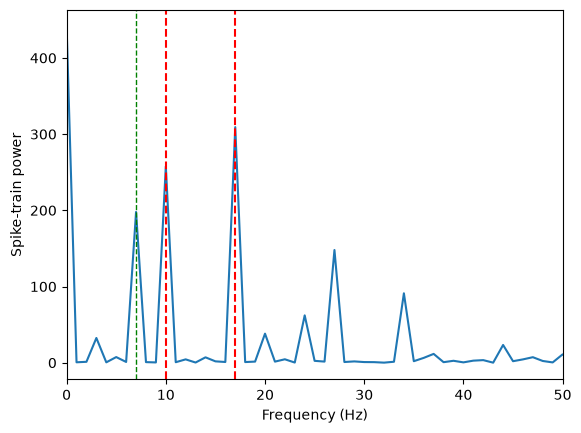

In [9]:
spectrum = np.abs(np.fft.rfft(spikes)) ** 2
frequencies = np.fft.rfftfreq(
    len(spikes),
    d=1 / samples,
)

plt.plot(frequencies, spectrum)
for frequency in target_frequencies:
    plt.axvline(
        x=frequency,
        color="red",
        linestyle="--",
        linewidth=1.5,
    )

for i in range(len(target_frequencies)):
    for j in range(i + 1, len(target_frequencies)):
        src = target_frequencies[i]
        dst = target_frequencies[j]
        dif = abs(dst - src)

        print(dif)
        plt.axvline(
            x=dif,
            color="green",
            linestyle="--",
            linewidth=1.0,
        )   
    

plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Spike-train power")
plt.show()